In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [5]:
df['species']=encoder.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df=df[df['species']!=0][['sepal_width','petal_length','species']]
df.sample()

,sepal_width,petal_length,species
143,3.2,5.9,2


In [7]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


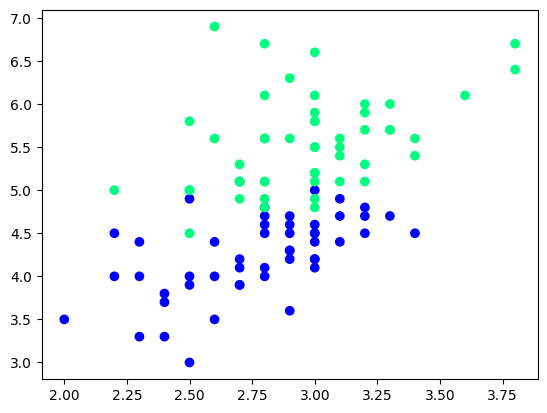

In [8]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [9]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [10]:
df_train

,sepal_width,petal_length,species
141,3.1,5.1,2
54,2.8,4.6,1
127,3.0,4.9,2
90,2.6,4.4,1
145,3.0,5.2,2
93,2.3,3.3,1
94,2.7,4.2,1
70,3.2,4.8,1
104,3.0,5.8,2
142,2.7,5.1,2


In [25]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

# Case1 - Bagging

In [26]:
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
54,2.8,4.6,1
127,3.0,4.9,2
93,2.3,3.3,1
127,3.0,4.9,2
94,2.7,4.2,1
93,2.3,3.3,1
93,2.3,3.3,1
145,3.0,5.2,2


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [28]:
dt_bag1=DecisionTreeClassifier()

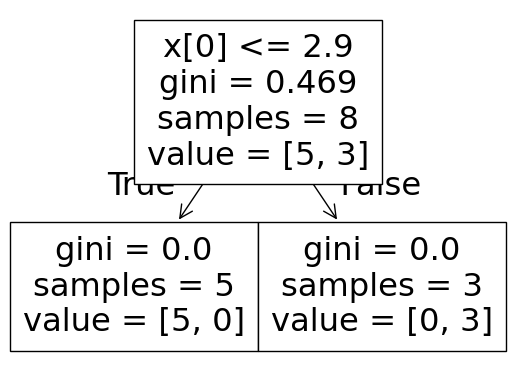

0.4


/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


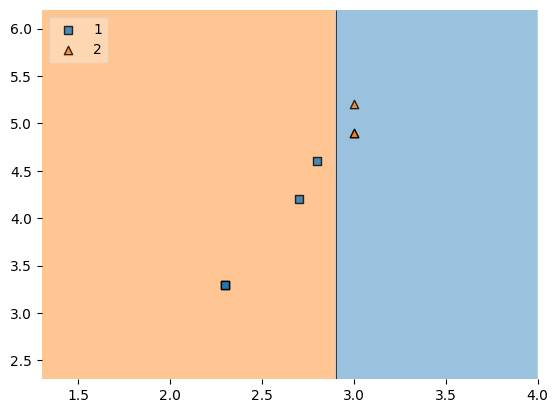

In [29]:
evaluate(dt_bag1,X,y)

In [32]:
y_test

array([1, 1, 1, 1, 2])

In [33]:
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
142,2.7,5.1,2
145,3.0,5.2,2
127,3.0,4.9,2
104,3.0,5.8,2
70,3.2,4.8,1
145,3.0,5.2,2
142,2.7,5.1,2
94,2.7,4.2,1


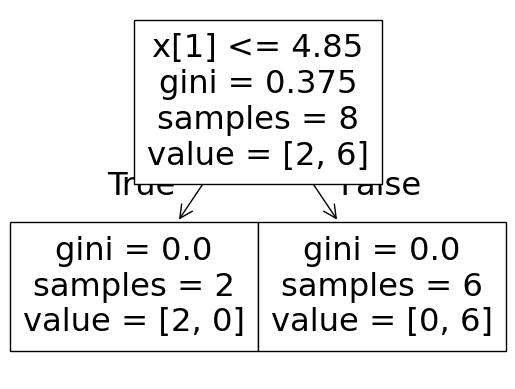

1.0


/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


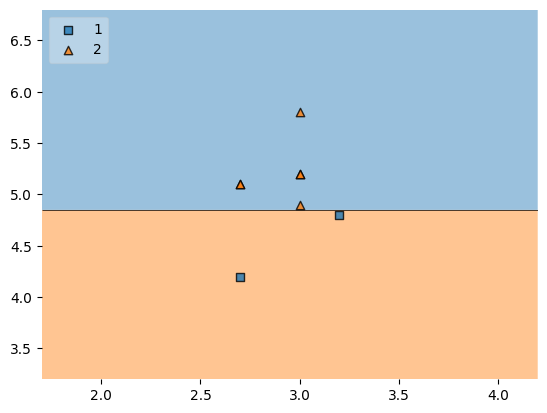

In [34]:
dt_bag2=DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [35]:
df_bag=df_train.sample(8,replace=True)

X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
104,3.0,5.8,2
54,2.8,4.6,1
142,2.7,5.1,2
70,3.2,4.8,1
127,3.0,4.9,2
93,2.3,3.3,1
90,2.6,4.4,1
141,3.1,5.1,2


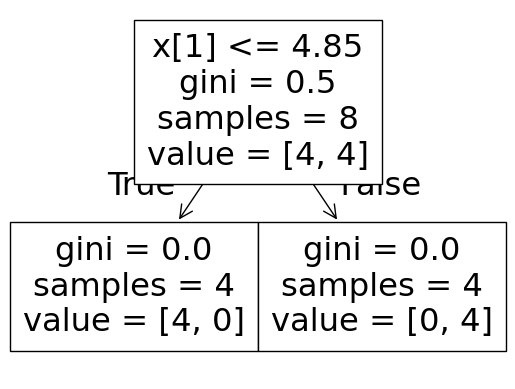

1.0


/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


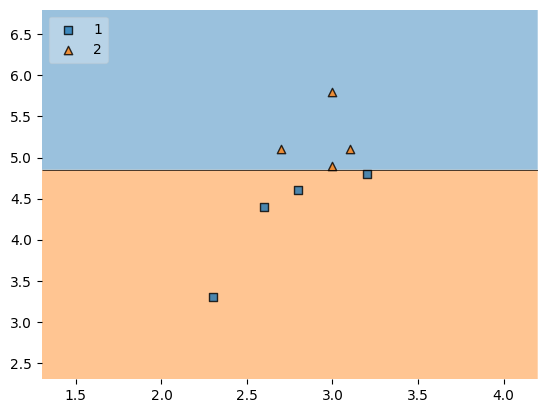

In [36]:
dt_bag3=DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [16]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred=clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

# Predict

In [37]:
df_test

,sepal_width,petal_length,species
108,2.5,5.8,2
100,3.3,6.0,2
110,3.2,5.1,2
149,3.0,5.1,2
59,2.7,3.9,1


In [41]:
print('Predictor 1',dt_bag1.predict(np.array([3.3,6.0]).reshape(1,2)))
print('Predictor 2',dt_bag2.predict(np.array([3.3,6.0]).reshape(1,2)))
print('Predictor 3',dt_bag3.predict(np.array([3.3,6.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/dragon99/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
